<a href="https://colab.research.google.com/github/mantashahaque/data_sience_lab_SE_A_37/blob/main/practical7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets, linear_model

In [ ]:
df = pd.read_csv('/content/HousingData.csv')
display(df.head())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [ ]:
df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
missing_values_count = df.isnull().sum()
display(missing_values_count)

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


### Handling Missing Values

I will impute the missing numerical values with the median of their respective columns. This approach is robust to outliers and maintains the distribution shape better than the mean for skewed data.

In [ ]:
# Impute missing values with the median
for column in ['CRIM', 'ZN', 'INDUS', 'CHAS', 'AGE', 'LSTAT']:
    if df[column].isnull().any():
        median_val = df[column].median()
        df[column] = df[column].fillna(median_val)

# Verify that there are no more missing values
missing_values_after_imputation = df.isnull().sum()
display("Missing values after imputation:", missing_values_after_imputation)

'Missing values after imputation:'

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


### Handling Duplicate Rows

Next, I will check for and remove any duplicate rows in the dataset to ensure data integrity.

In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
display(f"Number of duplicate rows found: {duplicate_rows}")

# Remove duplicate rows if any exist
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    display(f"Number of rows after removing duplicates: {df.shape[0]}")

'Number of duplicate rows found: 0'

### Building a Regression Model

Now that the data is cleaned, I will proceed to build a Linear Regression model. 'MEDV' will be the target variable, and all other columns will be used as features.

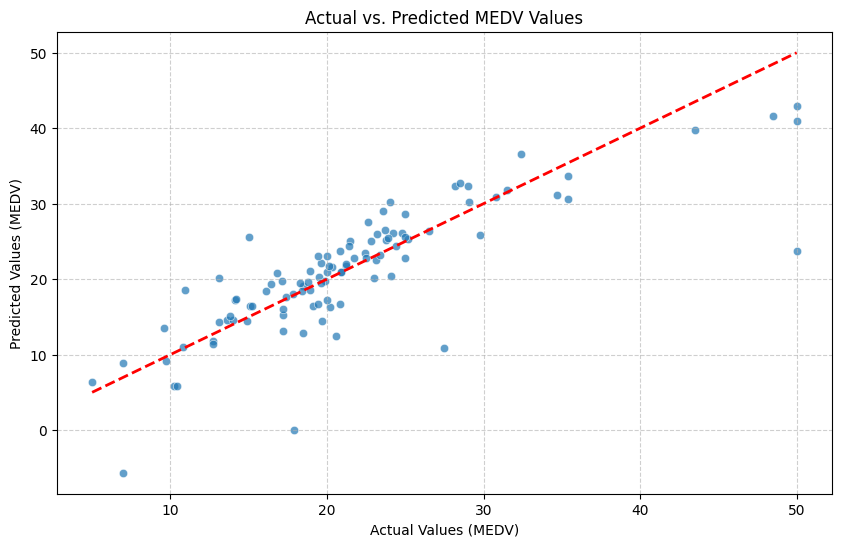

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Diagonal line for perfect prediction
plt.xlabel('Actual Values (MEDV)')
plt.ylabel('Predicted Values (MEDV)')
plt.title('Actual vs. Predicted MEDV Values')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Define features (X) and target (y)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(f"X_train shape: {X_train.shape}")
display(f"X_test shape: {X_test.shape}")
display(f"y_train shape: {y_train.shape}")
display(f"y_test shape: {y_test.shape}")

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

display(f"Mean Squared Error: {mse:.2f}")
display(f"R-squared: {r2:.2f}")

# Optionally, display model coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
display("Model Coefficients:", coefficients.sort_values(by='Coefficient', ascending=False))

'X_train shape: (404, 13)'

'X_test shape: (102, 13)'

'y_train shape: (404,)'

'y_test shape: (102,)'

'Mean Squared Error: 25.00'

'R-squared: 0.66'

'Model Coefficients:'

,Feature,Coefficient
5,RM,4.717140
3,CHAS,3.279482
8,RAD,0.218217
1,ZN,0.028179
11,B,0.012033
9,TAX,-0.009054
6,AGE,-0.018190
2,INDUS,-0.025656
0,CRIM,-0.112574
12,LSTAT,-0.444167
